#  High-temperature susceptibility data analysis

In this notebook, a contribution is downloaded from the MagIC database. Susceptibility-temperature ($\chi$-T) data contained within it are extracted. The user has the option to correct for the diamagnetic signal of the measurement instrument and holder (*optional*) and to smooth the data prior to further analysis (*optional*).

The notebook is to be run cell-by-cell to allow users to select corrections/filters as needed. The code below brings in example magnetite data from the rock magnetic bestiary. Any MagIC contribution that contains $\chi$-T data can be used in place of this example dataset.

This notebook focuses on importing, correcting, and plotting $\chi$-T data; quantitative Curie temperature estimation is demonstrated in the companion [Curie temperature estimation notebook](curie_temperature_estimation.ipynb).

## Install and import packages

In [1]:
import pmagpy.rockmag as rmag
import pmagpy.ipmag as ipmag
import pmagpy.contribution_builder as cb

from bokeh.io import output_notebook
output_notebook(hide_banner=True)

## Import data

We follow one of the approaches as in the `rockmag_data_unpack.ipynb` notebook to bring the MagIC data into the notebook as a Contribution.

In [2]:
#define these three parameters to match your data
magic_id = '20354'
share_key = '2f33e164-df55-4548-8d28-5b715683ae43'
dir_path = 'example_data/X-T'

result, magic_file = ipmag.download_magic_from_id(magic_id, directory=dir_path, share_key=share_key)
ipmag.unpack_magic(magic_file, dir_path, print_progress=False)
contribution = cb.Contribution(dir_path)
measurements = contribution.tables['measurements'].df

Download successful. File saved to: example_data/X-T/magic_contribution_20354.txt
1  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/contribution.txt
2  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/locations.txt
2  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/sites.txt
43  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/samples.txt
201  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/specimens.txt


92035  records written to file  /Users/penokean/0000_GitHub/RockmagPy-notebooks/thermomagnetic_notebooks/example_data/X-T/measurements.txt


-I- Using online data model


-I- Getting method codes from earthref.org


-I- Importing controlled vocabularies from https://earthref.org


## The project export contains data from all the experiments

Each measurement in a MagIC measurements table has a `method_codes` value. These method codes come from a "controlled vocabulary" (https://www2.earthref.org/MagIC/method-codes). 

In the method codes used for the example contribution:
- `LP` refers to lab protocol
- `X-T` refers to susceptibility vs. temperature experiments done on the Kappabridge

In [3]:
measurements = measurements[measurements['method_codes'].str.contains('LP-X-T', na=False)]

## Select a $\chi$-T experiment

*Creates a dropdown to select specimens with $\chi$-T data.*

In [4]:
specimen, experiment = rmag.specimen_experiment_selection_interactive(measurements)

Dropdown(description='specimen:', options=('maghemite_AA_ 39951-01', 'maghemite_SkySpring 3315DX-01', 'maghemi…

Dropdown(description='Experiment:', options=('IRM-BigRed-LP-X:LP-X-T:LP-X-F-9650',), value='IRM-BigRed-LP-X:LP…

## Plot $\chi$-T data

If the `remove_holder` parameter is set to be `True`, we assume that the lowest susceptibility value during the whole measurement is the holder signal. This assumption relies on this value being after the specimen is heated above the critical temperature such that it is paramagnetic and the holder signal is dominant.

In [5]:
selected_experiment = measurements[(measurements['specimen']==specimen.value) & 
                                      (measurements['experiment']==experiment.value)].reset_index(drop=True)

rmag.plot_chi_T(selected_experiment, 
              temp_unit='C', 
              remove_holder=True, 
              plot_derivative=False,
              plot_inverse=False)

## Plot $\chi$-T data with derivative

In this example, the experiment ```'IRM-KappaF-LP-X-T-3410'``` is selected by name (rather than with the dropdown above) and is plotted together with its derivative by setting ```plot_derivative=True```.

In [6]:
selected_experiment = rmag.experiment_selection(measurements, 'IRM-KappaF-LP-X-T-3410')

rmag.plot_chi_T(selected_experiment, 
              temp_unit='C', 
              remove_holder=True, 
              plot_derivative=True,
              plot_inverse=False)

### Inverse susceptibility

Above its Curie temperature (*Tc*) a mineral phase is paramagnetic, so the inverse susceptibility 1/$\chi$ has a linear positive slope above *Tc* ([Petrovský and Kapička, 2006](https://doi.org/10.1029/2006JB004507)). Setting `plot_inverse=True` in `rmag.plot_chi_T()` adds the 1/$\chi$ panel for visual inspection of where Curie–Weiss (paramagnetic) behavior sets in.

Quantitative Curie temperature estimation from these data — inflection point, maximum curvature, two-tangent, inverse susceptibility (Curie–Weiss), and Landau fitting, with their physical basis and caveats — is demonstrated in the companion [Curie temperature estimation notebook](curie_temperature_estimation.ipynb).

In [7]:
rmag.plot_chi_T(selected_experiment, 
              temp_unit='C', 
              remove_holder=True, 
              plot_derivative=True,
              plot_inverse=True,)

## Appendix: determining the best temperature window for smoothing

Smoothing of $\chi$-T data prior to analysis is optional and is applied through the `smooth_window` parameter of `rmag.plot_chi_T()` (a running average with the given temperature window; the default of `smooth_window=0` applies no smoothing). Rather than picking a window size arbitrarily, the window size can be chosen based on the trade-off between smoothness and misfit.

The `rmag.optimize_moving_average_window()` function plots the **model roughness** against the **root mean square error** of the model **(note that the y-axis is inverted)** (a measure of the difference between the running average and the data). Each point on the graph is for a different temperature window size. The knee in the curve (the break of slope) can be interpreted as the optimal temperature window for smoothing. At this point (window) there is a decent trade off between the smoothness of the model (the running average) and error on the model.

Set values for `min_temp_window` and `max_temp_window` to set the temperature range for exploring the rms and variance tradeoff.

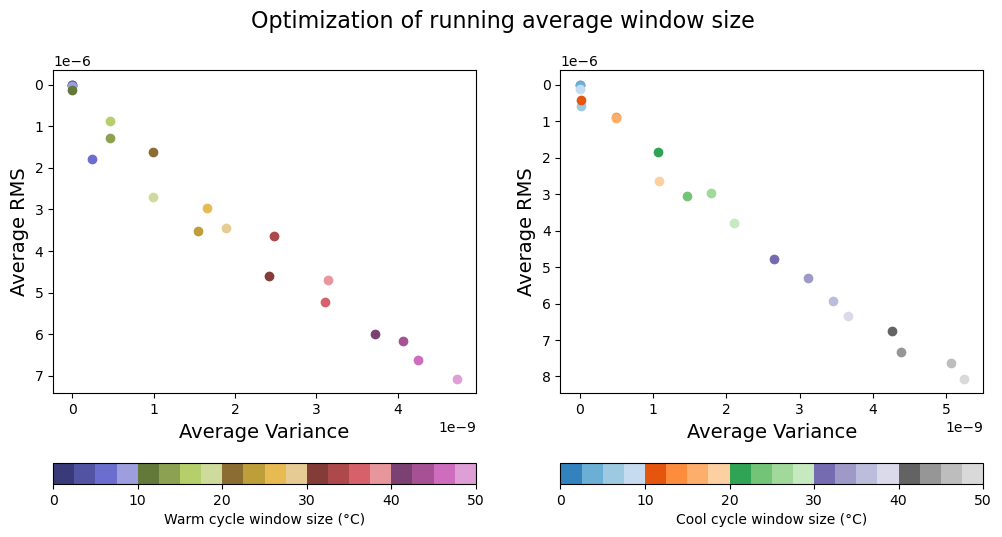

In [8]:
min_temp_window = 0
max_temp_window = 50
steps = 20
fig, ax = rmag.optimize_moving_average_window(selected_experiment, min_temp_window, max_temp_window, steps=steps)

Upon inspecting the plot, a smoothing window size of about 10 K seems to be a good choice for this dataset. The chosen window can then be applied by passing it to the `smooth_window` parameter of `rmag.plot_chi_T()`:

In [9]:
rmag.plot_chi_T(selected_experiment,
              temp_unit='C',
              remove_holder=True,
              plot_derivative=True,
              smooth_window=10)

## References

Petrovský, E., & Kapička, A. (2006). On determination of the Curie point from thermomagnetic curves. *Journal of Geophysical Research: Solid Earth*, 111, B12S27. [https://doi.org/10.1029/2006JB004507](https://doi.org/10.1029/2006JB004507)

Additional references for the Curie temperature estimation methods are given in the companion [Curie temperature estimation notebook](curie_temperature_estimation.ipynb).